**Libraries**

In [169]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDRegressor, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score

from sklearn.datasets import fetch_california_housing

**Data Loading**

In [170]:
# Dataset load
Housing_data = fetch_california_housing()

In [171]:
# Dataset base Structure
Housing_data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [172]:
Housing_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [173]:
# New dataset Structure (Dataframe)

data_frame = pd.DataFrame(data=Housing_data.data, columns=Housing_data.feature_names)
data_frame = pd.concat([data_frame, pd.DataFrame(data=Housing_data.target, columns=['Target'])], axis=1)

data_frame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**EDA**

In [174]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [175]:
data_frame.duplicated().sum()

np.int64(0)

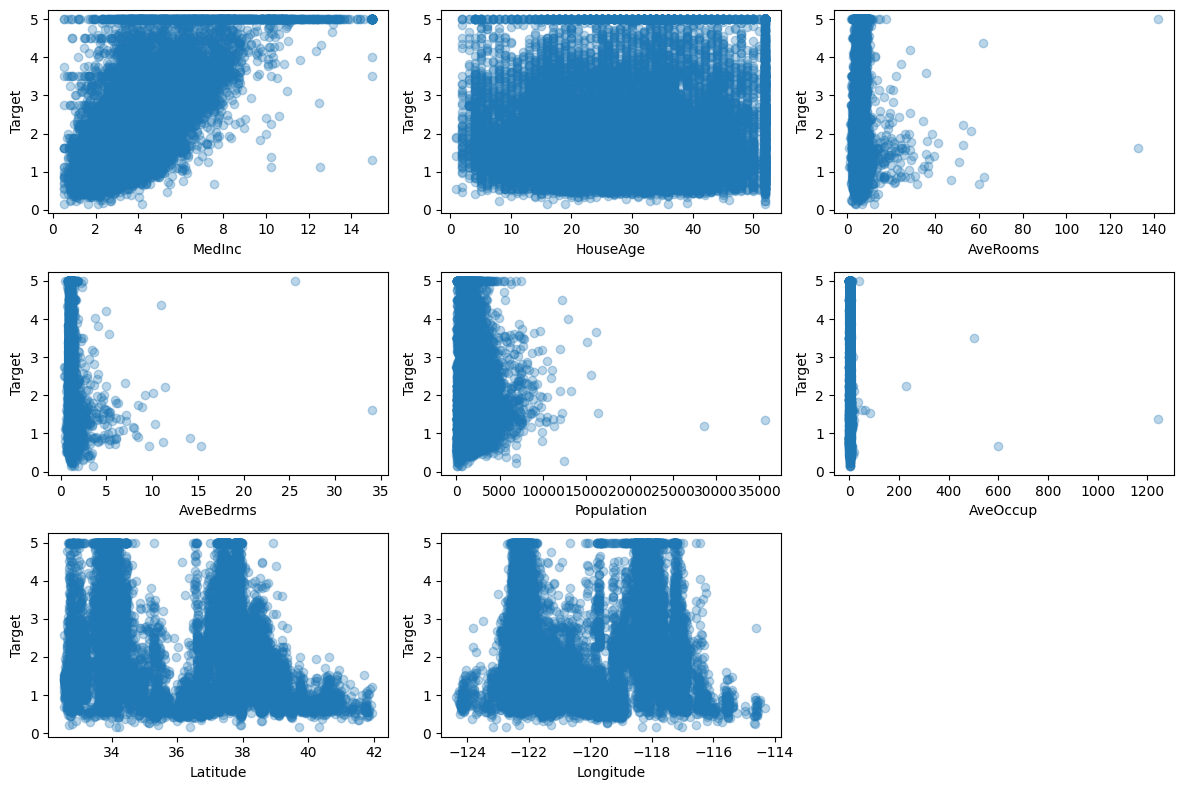

In [176]:
# Data Ploting
features = data_frame.columns.drop("Target")

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(data_frame[col], data_frame["Target"], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("Target")

plt.tight_layout()
plt.show()

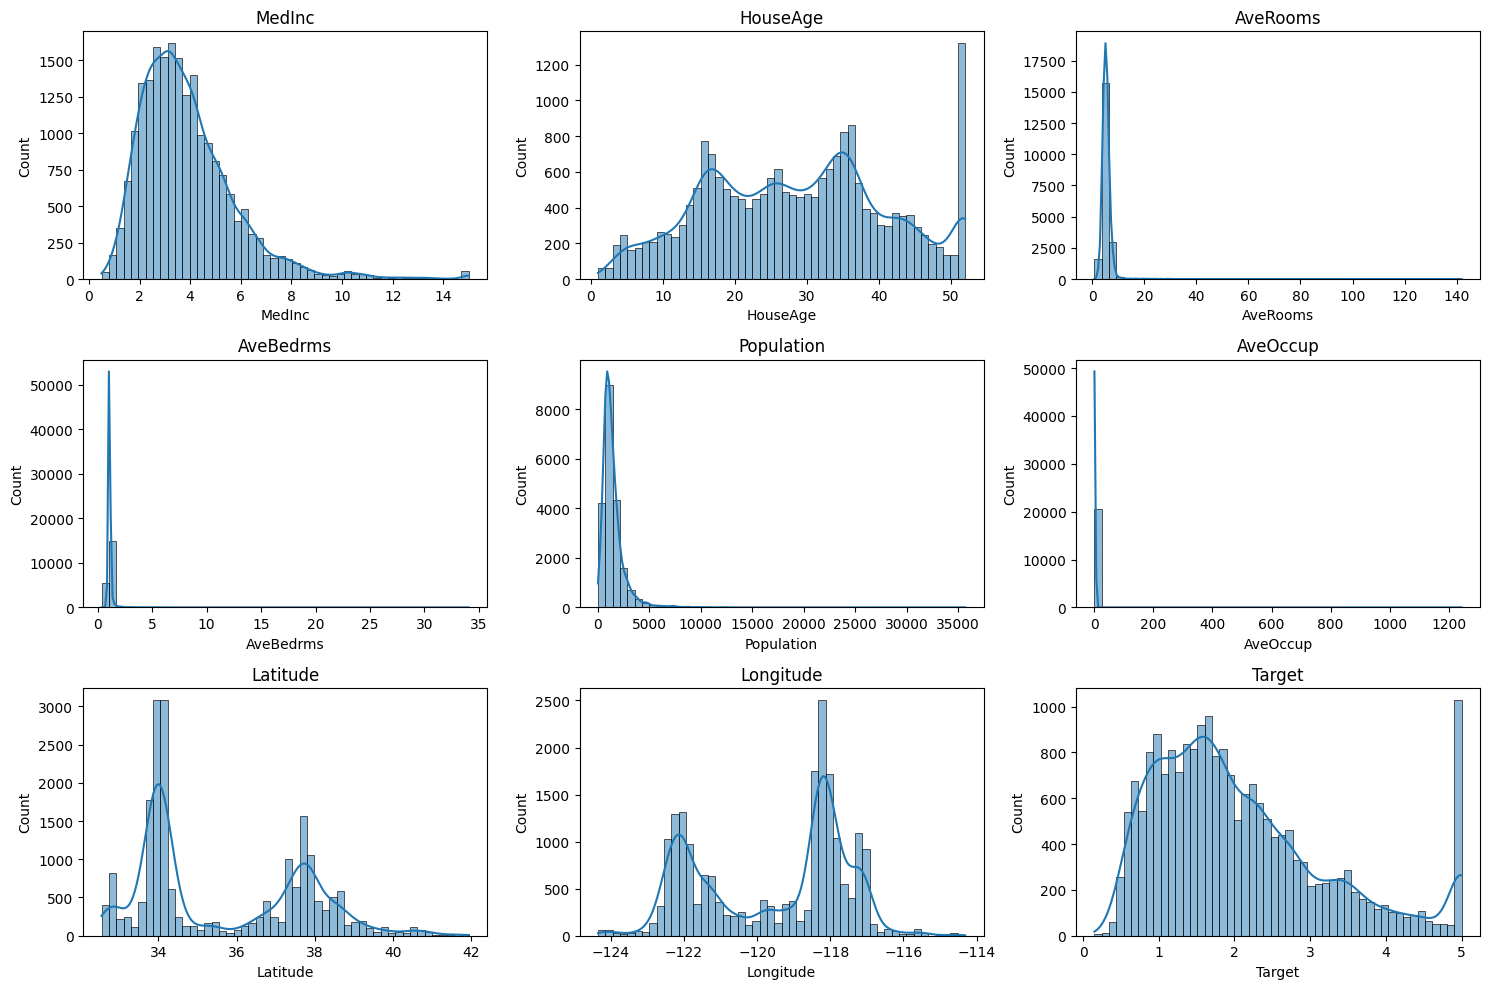

In [177]:
# Data spread (distribution)
features = data_frame.columns

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data_frame[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [178]:
# EDA
data_frame["AveOccup"].describe()

,AveOccup
count,20640.000000
mean,3.070655
std,10.386050
min,0.692308
25%,2.429741
50%,2.818116
75%,3.282261
max,1243.333333


In [179]:
# EDA
data_frame[data_frame["AveOccup"] > 10].sort_values(by="AveOccup", ascending=False).describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,3.938989,29.972973,5.688776,1.171687,2615.648649,87.786668,36.105135,-119.856757,1.816920
std,3.132148,15.146482,3.872472,0.499331,2306.519868,232.632680,2.156088,2.050462,1.304639
min,0.499900,5.000000,2.111111,0.625000,13.000000,10.153846,32.560000,-122.500000,0.425000
25%,1.912500,17.000000,3.166667,0.937500,822.000000,12.296089,34.070000,-121.290000,1.154000
50%,3.419100,29.000000,5.123810,1.074713,1722.000000,15.602941,36.510000,-120.650000,1.425000
75%,4.302900,41.000000,6.468000,1.142857,4198.000000,21.333333,37.790000,-118.170000,2.125000
max,15.000100,52.000000,24.500000,3.500000,8733.000000,1243.333333,40.410000,-115.220000,5.000010


**Model Building and Evaluation -- Before Feature Enginnering --**


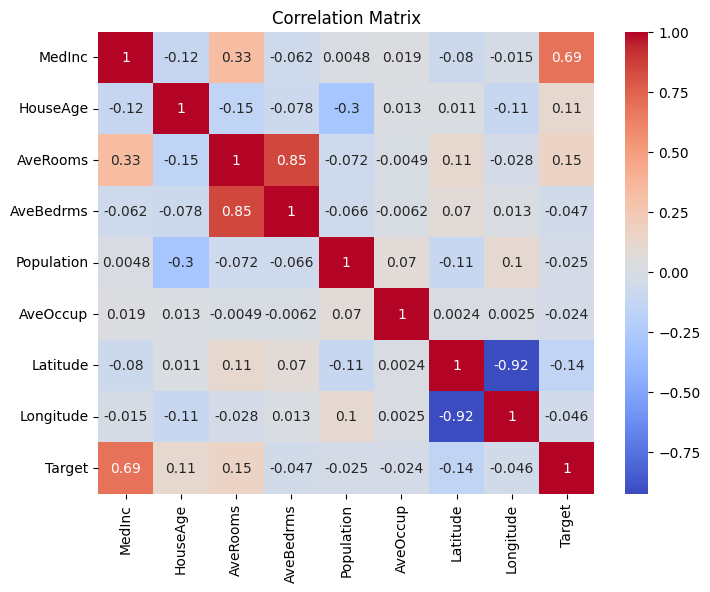

In [180]:
# Feture Correlation
plt.figure(figsize=(8,6))
sns.heatmap(data_frame.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [181]:
X_train, X_test, y_train, y_test = train_test_split(data_frame.drop("Target", axis=1), data_frame["Target"], test_size=0.2, random_state=42)

In [182]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [183]:
#model = SGDRegressor()
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [184]:
y_pred = model.predict(x_test_scaled)

In [185]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
R²:   0.5758


In [186]:
for name, coef in zip(X_train.columns, model.coef_):
    print(f"{name}: {coef}")

MedInc: 0.8543830309268546
HouseAge: 0.12254623807840737
AveRooms: -0.2944101344732999
AveBedrms: 0.3392594905944844
Population: -0.0023077231458302765
AveOccup: -0.04082910308508747
Latitude: -0.896928876638665
Longitude: -0.8698417752417177


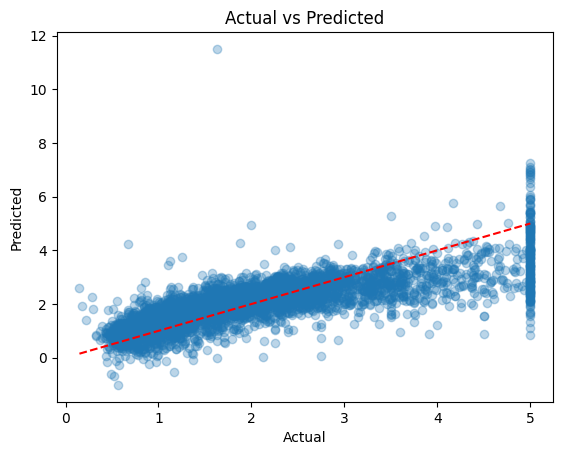

In [187]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [188]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"CV R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std R²:  {cv_scores.std():.4f}")

CV R² Scores: [0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]
Mean R²: 0.6115
Std R²:  0.0065


**Feature Engineering**

In [189]:
# Feature Engineering

data_frame["AveOccup"] = data_frame["AveOccup"].clip(upper=10)
data_frame["Population"] = np.log1p(data_frame["Population"])
data_frame["Rooms_per_Person"] = data_frame["AveRooms"] / data_frame["AveOccup"]
data_frame = data_frame[data_frame["Rooms_per_Person"] < 10]
kmeans = KMeans(n_clusters=5, random_state=42)
data_frame["LocationCluster"] = kmeans.fit_predict(data_frame[["Latitude", "Longitude"]])
data_frame["Bedrooms_per_Room"] = data_frame["AveBedrms"] / data_frame["AveRooms"]

#data_frame = data_frame.drop("Latitude", axis=1)   affect
#data_frame = data_frame.drop("Longitude", axis=1)  affect
#data_frame = data_frame.drop("AveBedrms", axis=1) no impact

data_frame.describe()

/tmp/ipykernel_23936/2780459985.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame["LocationCluster"] = kmeans.fit_predict(data_frame[["Latitude", "Longitude"]])
/tmp/ipykernel_23936/2780459985.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame["Bedrooms_per_Room"] = data_frame["AveBedrms"] / data_frame["AveRooms"]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target,Rooms_per_Person,LocationCluster,Bedrooms_per_Room
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000
mean,3.871380,28.666165,5.354251,1.081088,7.030151,2.932841,35.627164,-119.569898,2.069284,1.941421,0.952656,0.213088
std,1.900031,12.581856,1.537216,0.226375,0.728944,0.821127,2.133792,2.004140,1.154174,0.704223,1.325939,0.058063
min,0.499900,1.000000,0.846154,0.333333,1.386294,0.750000,32.540000,-124.350000,0.149990,0.211111,0.000000,0.100000
25%,2.563925,18.000000,4.438596,1.005917,6.673298,2.431675,33.930000,-121.800000,1.197250,1.521369,0.000000,0.175421
50%,3.535500,29.000000,5.225898,1.048559,7.063904,2.820312,34.250000,-118.490000,1.798000,1.936927,0.000000,0.203183
75%,4.743700,37.000000,6.045872,1.099031,7.454141,3.283005,37.710000,-118.010000,2.649750,2.293233,1.000000,0.239843
max,15.000100,52.000000,28.432143,6.500000,10.482430,10.000000,41.950000,-114.310000,5.000010,9.926036,4.000000,1.000000


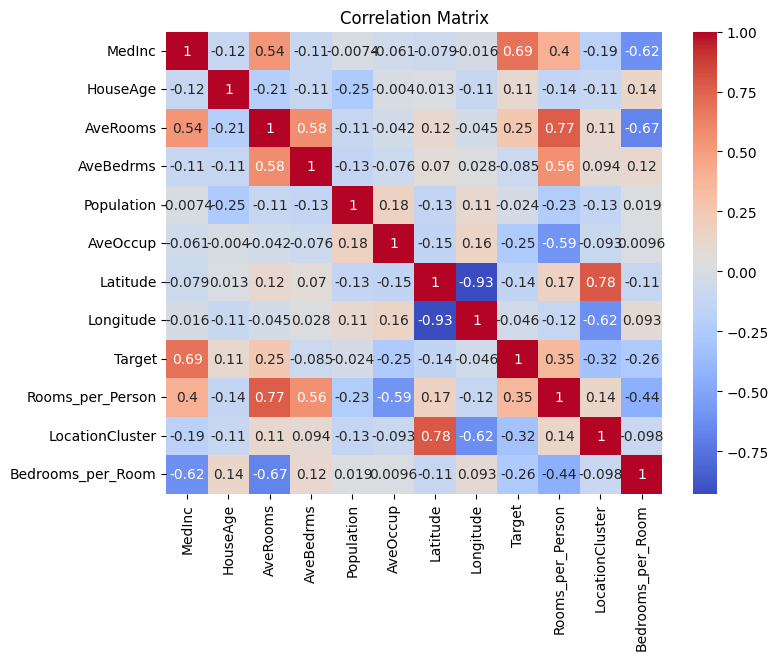

In [190]:
# Feture Correlation
plt.figure(figsize=(8,6))
sns.heatmap(data_frame.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Model Building and Evaluation -- After Feature Enginnering --**





In [191]:
X_train, X_test, y_train, y_test = train_test_split(data_frame.drop("Target", axis=1), data_frame["Target"], test_size=0.2, random_state=42)

In [192]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [193]:
#model = SGDRegressor()
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [194]:
y_pred = model.predict(x_test_scaled)

In [195]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.4690
MSE:  0.4204
RMSE: 0.6484
R²:   0.6938


In [196]:
for name, coef in zip(X_train.columns, model.coef_):
    print(f"{name}: {coef}")

MedInc: 0.737558238715608
HouseAge: 0.11869732948309061
AveRooms: -0.17717061133066947
AveBedrms: -0.11525021623841122
Population: 0.04973345096912501
AveOccup: 0.021081571785259413
Latitude: -0.7879461129011931
Longitude: -0.7905179636366568
Rooms_per_Person: 0.503025944834848
LocationCluster: -0.09769338946960301
Bedrooms_per_Room: 0.23445196466207702


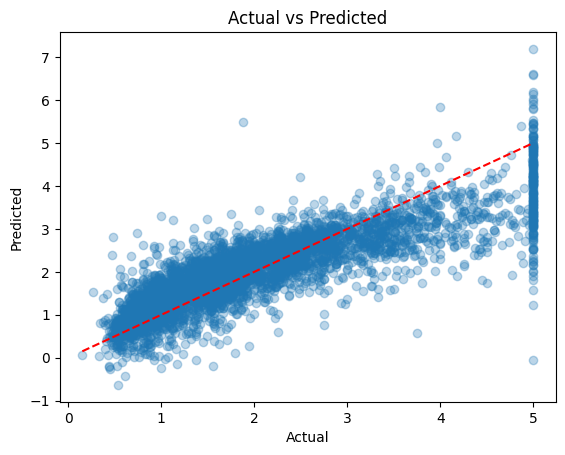

In [197]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [198]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"CV R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std R²:  {cv_scores.std():.4f}")

CV R² Scores: [0.65904767 0.66036266 0.67251085 0.68745323 0.68279132]
Mean R²: 0.6724
Std R²:  0.0115
